<a href="https://colab.research.google.com/github/subhashiitb/CodeBasics/blob/main/ML/LR-Example/9_decision_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h2 style='color:blue' align="center">Decision Tree Classification</h2>

In [1]:
import pandas as pd

In [4]:
url='https://raw.githubusercontent.com/subhashiitb/CodeBasics/refs/heads/main/ML/LR-Example/salaries.csv'
df = pd.read_csv(url)
df.head()

,company,job,degree,salary_more_then_100k
0,google,sales executive,bachelors,0
1,google,sales executive,masters,0
2,google,business manager,bachelors,1
3,google,business manager,masters,1
4,google,computer programmer,bachelors,0


In [5]:
inputs = df.drop('salary_more_then_100k',axis='columns')

In [6]:
target = df['salary_more_then_100k']

In [9]:
from sklearn.preprocessing import LabelEncoder
le_company = LabelEncoder()
le_job = LabelEncoder()
le_degree = LabelEncoder()

In [11]:
le_company
le_job
le_degree

LabelEncoder()

In [17]:
inputs['company_n'] = le_company.fit_transform(inputs['company'])
inputs['job_n'] = le_job.fit_transform(inputs['job'])
inputs['degree_n'] = le_degree.fit_transform(inputs['degree'])

In [18]:
inputs

,company,job,degree,company_n,job_n,degree_n
0,google,sales executive,bachelors,2,2,0
1,google,sales executive,masters,2,2,1
2,google,business manager,bachelors,2,0,0
3,google,business manager,masters,2,0,1
4,google,computer programmer,bachelors,2,1,0
5,google,computer programmer,masters,2,1,1
6,abc pharma,sales executive,masters,0,2,1
7,abc pharma,computer programmer,bachelors,0,1,0
8,abc pharma,business manager,bachelors,0,0,0
9,abc pharma,business manager,masters,0,0,1


In [19]:
inputs_n = inputs.drop(['company','job','degree'],axis='columns')

In [20]:
inputs_n

,company_n,job_n,degree_n
0,2,2,0
1,2,2,1
2,2,0,0
3,2,0,1
4,2,1,0
5,2,1,1
6,0,2,1
7,0,1,0
8,0,0,0
9,0,0,1


In [21]:
target

,salary_more_then_100k
0,0
1,0
2,1
3,1
4,0
5,1
6,0
7,0
8,0
9,1


In [22]:
from sklearn import tree
model = tree.DecisionTreeClassifier()

In [27]:
model.fit(inputs_n, target)

DecisionTreeClassifier()

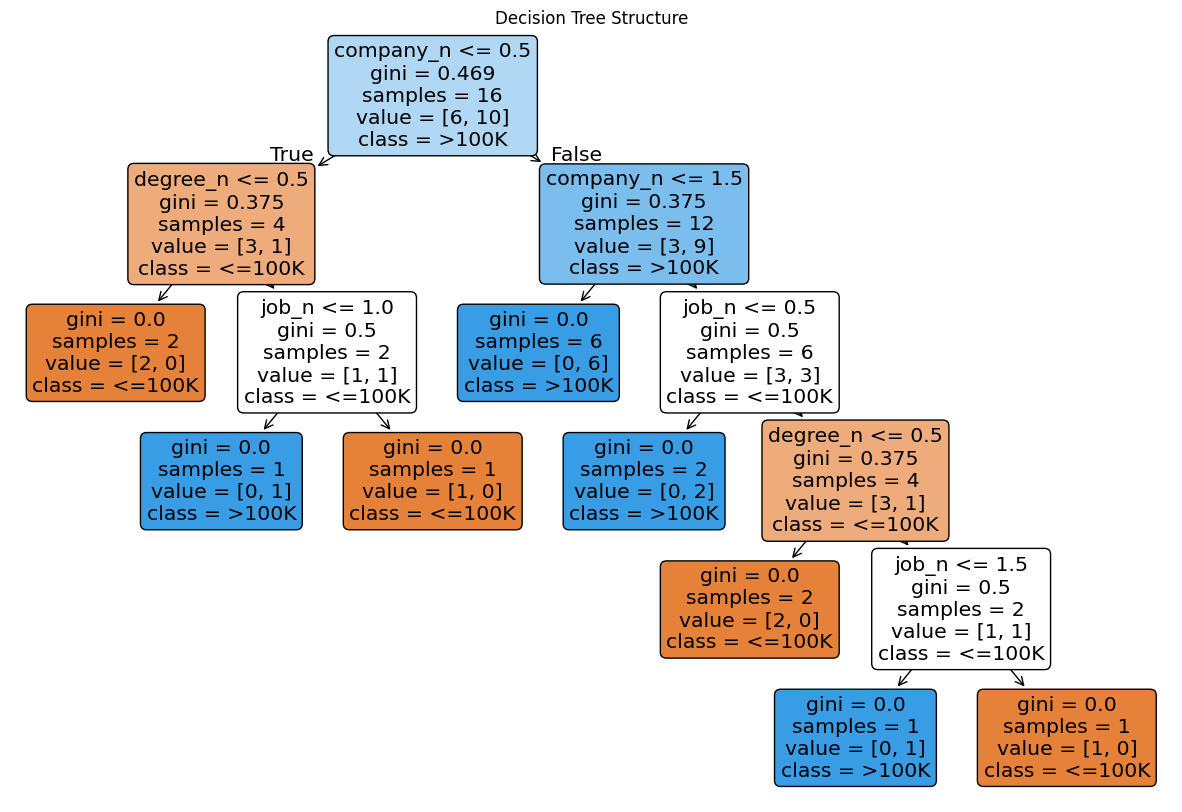

In [32]:
import matplotlib.pyplot as plt
from sklearn import tree

plt.figure(figsize=(15,10))
tree.plot_tree(model,
               feature_names=inputs_n.columns,  # Use column names from inputs_n as feature names
               class_names=['<=100K', '>100K'], # Assuming 0 is <=100K and 1 is >100K
               filled=True,
               rounded=True)
plt.title("Decision Tree Structure")
plt.show()

In [33]:
model.score(inputs_n,target)

1.0

**Is salary of Google, Computer Engineer, Bachelors degree > 100 k ?**

In [25]:
model.predict([[2,1,0]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

**Is salary of Google, Computer Engineer, Masters degree > 100 k ?**

In [26]:
model.predict([[2,1,1]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

**Exercise: Build decision tree model to predict survival based on certain parameters**

<img src="https://github.com/subhashiitb/CodeBasics/blob/main/ML/LR-Example/titanic.jpg?raw=1" height=200 width=400/>

CSV file is available to download at https://github.com/codebasics/py/blob/master/ML/9_decision_tree/Exercise/titanic.csv

##### In this file using following columns build a model to predict if person would survive or not,

1. Pclass
1. Sex
1. Age
1. Fare

##### Calculate score of your model